### Uber Pickups Analysis 

In this project, we are going to analyse the Uber Pickups in New York City for August 2014, `uber-raw-data-aug14.csv`.

#### Keeping the dataset ready before questions

### ABOUT THE DATASET

The dataset contains following details of Aug 2014 and July 2014
* **Date/Time** : The date and time of the Uber pickup
* **Lat** : The latitude of the Uber pickup
* **Lon** : The longitude of the Uber pickup
* **Base** : The TLC (Taxi & Limousine Commission) base company code affiliated with the Uber pickup

These files are named:

* `uber-raw-data-aug14.csv`
* `uber-raw-data-jul14.csv`

The `base` codes are for the following Uber bases (In the parentheses, we have code names in German which are used internally by Uber to categorize and manage their various service offerings.) :

* **B02512 (Unter):** This corresponds to the Uber service category "UberX", which is the basic and most common service offering.
* **B02598 (Hinter):** This corresponds to the Uber service category "UberPOOL", which allows riders heading in the same direction to share a ride and split the cost.
* **B02617 (Weiter):** This corresponds to the Uber service category "UberXL", which offers larger vehicles such as SUVs and minivans for accommodating more passengers.
* **B02682 (Schmecken):** This corresponds to the Uber service category "UberSELECT", which provides premium rides with high-end vehicles.
* **B02764 (Danach-NY):** This corresponds to the Uber service category "UberWAV", which offers wheelchair-accessible vehicles for riders with accessibility needs.
* **B02765 (Grun):** This corresponds to the Uber service category "UberBLACK", which provides luxury black car services with professional drivers.
* **B02835 (Dreist):** This corresponds to the Uber service category "UberSUV", which offers larger luxury vehicles for accommodating more passengers.
* **B02836 (Drinnen):** This corresponds to the Uber service category "UberLUX", which provides high-end luxury vehicles for a premium ride experience.

In [12]:
import pandas as pd
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./Data/uber-raw-data-aug14.csv')
df.head()

,Date/Time,Lat,Lon,Base
0,8/1/2014 0:03:00,40.7366,-73.9906,B02512
1,8/1/2014 0:09:00,40.7260,-73.9918,B02512
2,8/1/2014 0:12:00,40.7209,-74.0507,B02512
3,8/1/2014 0:12:00,40.7387,-73.9856,B02512
4,8/1/2014 0:12:00,40.7323,-74.0077,B02512


#### Q1. On what date did we see the most number of Uber pickups?


In [13]:
# Convert the 'Date/Time' column to datetime format
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
# Group by date and count the number of pickups

count_per_date = df.groupby(df['Date/Time'].dt.date)['Date/Time'].count()

# Find the date with the highest number of pickups

date_with_highest_pickups = count_per_date.idxmax()
print(date_with_highest_pickups)

2014-08-07


#### Q.2 How many Uber pickups were made on the date with the highest number of pickups?


In [14]:
# Filter the DataFrame to include only the rows for the date with the highest number of pickups

count_per_date = df.groupby(df['Date/Time'].dt.date).size()
date_with_highest_pickups = count_per_date.idxmax()
filtered_df = df[df['Date/Time'].dt.date == date_with_highest_pickups]

# Get the count of pickups on the highest date

count_of_pickups = filtered_df.shape[0]
print(count_of_pickups)


32759


#### Q.3 How many unique TLC base companies are affiliated with the Uber pickups in the dataset?


In [15]:
# Count the number of unique TLC base companies

num_unique_companies = df['Base'].nunique()

print(num_unique_companies)

5


#### Q.4 Which TLC base company had the highest number of pickups?


In [16]:
# Group by TLC base company and count the number of pickups

pickup_counts = df.groupby('Base')['Date/Time'].count()

# Find the TLC base company with the highest number of pickups

sorted_pickup_counts = pickup_counts.sort_values(ascending=False)

top_company = sorted_pickup_counts.idxmax()
print(top_company)

B02617


#### Q.5 How many Uber pickups were made at each unique TLC base company?


In [17]:
# Group by TLC base company and count the number of pickups

sorted_pickup_counts = pickup_counts.sort_values(ascending=False)
top_companies = sorted_pickup_counts.head()
print(top_companies)

Base
B02617    355803
B02598    220129
B02682    173280
B02764     48591
B02512     31472
Name: Date/Time, dtype: int64


#### Q.6 Determining the busiest time of day for Uber pickups based on the date/time column?


In [18]:
# Extract the hour from the 'Date/Time' column

df['Hour'] = df['Date/Time'].dt.hour

# Group by hour and count the number of pickups

pickup_counts_by_hour = df.groupby('Hour').size()

# Find the hour with the highest number of pickups

hour_with_highest_pickups = pickup_counts_by_hour.idxmax()
print(hour_with_highest_pickups)


17


#### Q.7  Creating a bar chart, line plot to represent the number of Uber pickups over time?


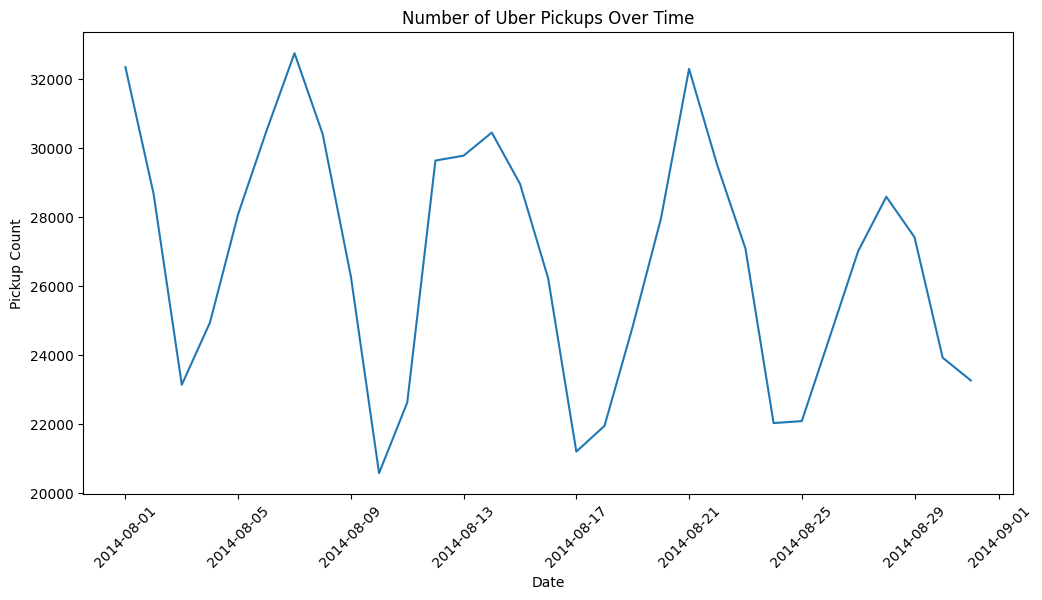

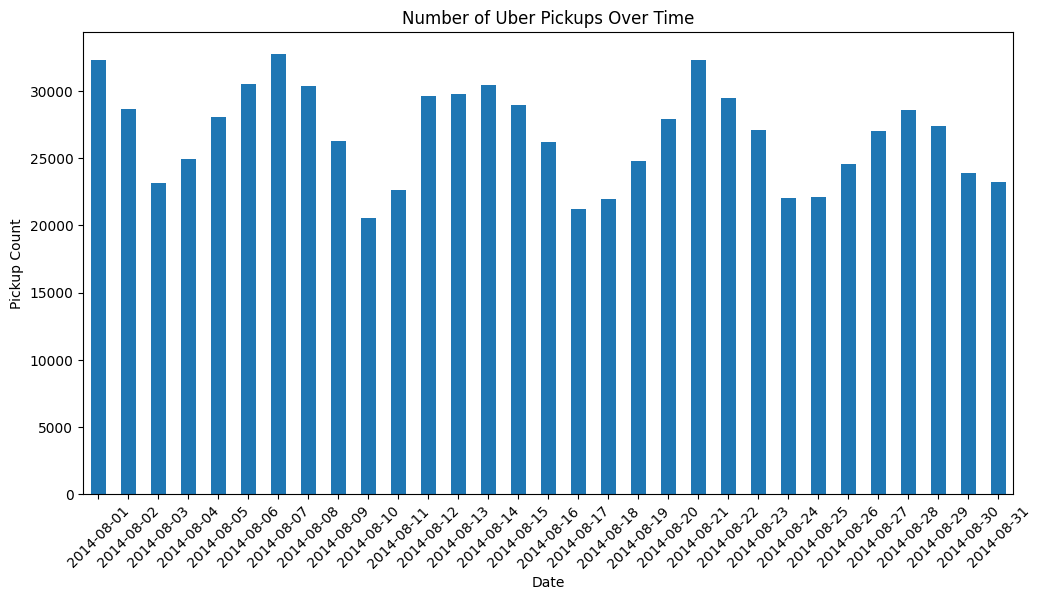

In [19]:
import matplotlib.pyplot as plt

# Group by date and count the number of pickups

pickup_counts_by_date = df.groupby(df['Date/Time'].dt.date).size()

# Create a line plot to visualize the number of pickups over time
plt.figure(figsize=(12, 6))
pickup_counts_by_date.plot()
plt.title('Number of Uber Pickups Over Time')
plt.xlabel('Date')
plt.ylabel('Pickup Count')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
pickup_counts_by_date.plot(kind='bar')
plt.title('Number of Uber Pickups Over Time')
plt.xlabel('Date')
plt.ylabel('Pickup Count')
plt.xticks(rotation=45)
plt.show()

#### Q8.  Creating a scatter plot to visualize the distribution of Uber pickups based on latitude and longitude?



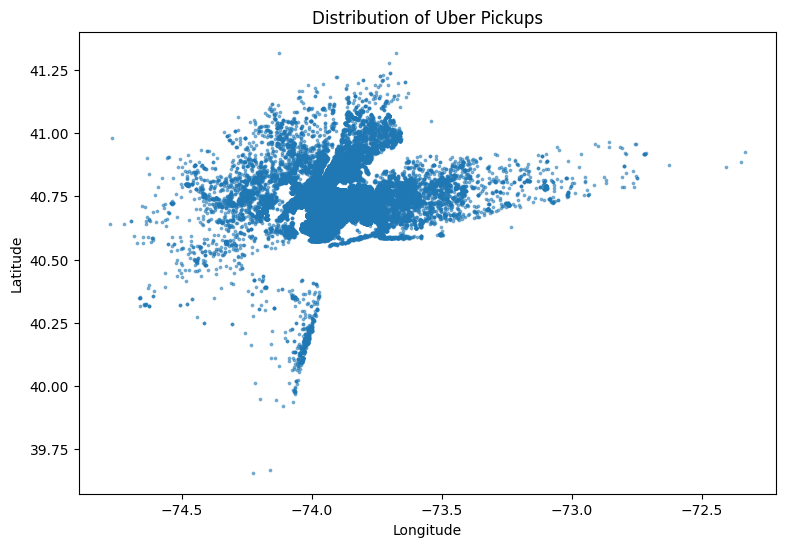

In [20]:
# Create a scatter plot to visualize the distribution of Uber pickups based on latitude and longitude
plt.figure(figsize=(9, 6))
plt.scatter(df['Lon'], df['Lat'], s= 3, alpha= 0.5)
plt.title('Distribution of Uber Pickups')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

#### Q9.  Creating a bar chart to compare the number of Uber pickups for each TLC base company?


Base
B02617    355803
B02598    220129
B02682    173280
B02764     48591
B02512     31472
Name: Date/Time, dtype: int64


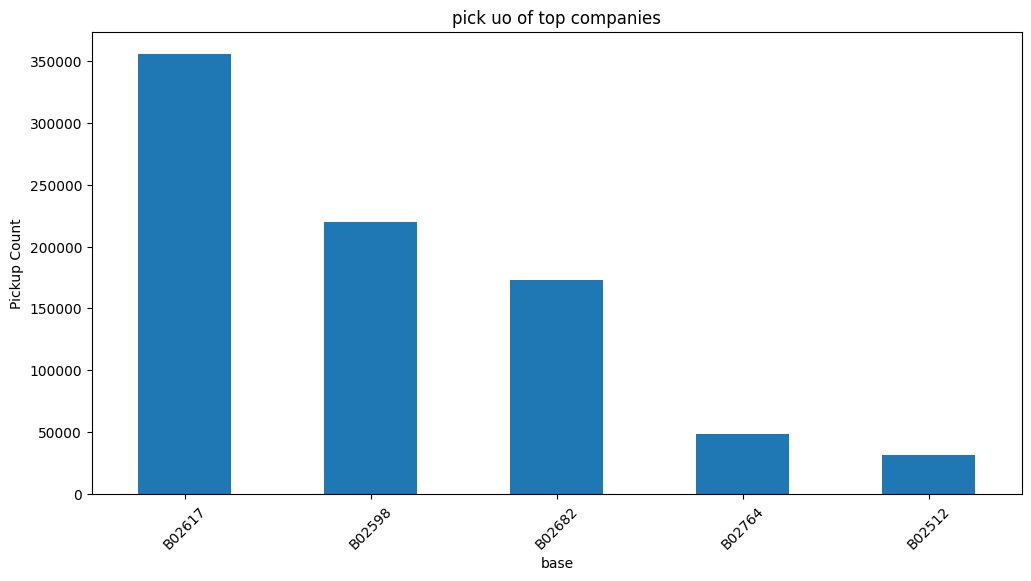

In [21]:
# Create a bar chart to compare the number of Uber pickups for each TLC base company

sorted_pickup_counts = pickup_counts.sort_values(ascending=False)
top_companies = sorted_pickup_counts.head()
print(top_companies)

plt.figure(figsize=(12, 6))
top_companies.plot(kind='bar')
plt.title('pick uo of top companies')
plt.xlabel('base')
plt.ylabel('Pickup Count')
plt.xticks(rotation=45)
plt.show()

#### Q10.  Creating a pie chart to display the percentage distribution of Uber pickups for each day of the week?


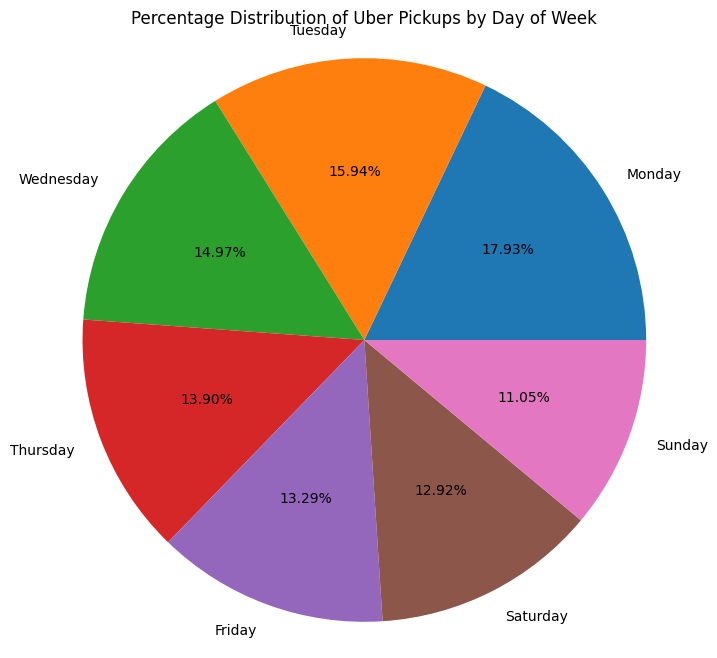

In [22]:
# Group by day of the week and count the number of pickups

df['DayOfWeek'] = df['Date/Time'].dt.dayofweek
pickup_counts_by_day = df['DayOfWeek'].value_counts()
pickup_percentages = pickup_counts_by_day / pickup_counts_by_day.sum() * 100
# Create a pie chart to display the percentage distribution of Uber pickups for each day of the week

labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(8, 8))
plt.pie(pickup_percentages, labels=labels, autopct='%1.2f%%')
plt.title('Percentage Distribution of Uber Pickups by Day of Week')
plt.axis('equal')
plt.show()